# 01 · Exploración y ETL — Steam Reviews (100M+)

Objetivo de este notebook:

1. Inspeccionar el esquema de los datos.
2. Explorar distribuciones básicas (usuarios, juegos, balance de clases, nulos).
3. Limpiar, tipificar y codificar los IDs a enteros consecutivos (`int32`) para que la matriz sparse del notebook de modelado sea mas liviana.
4. Guardar un parquet limpio + los mapeos de IDs, listos para el notebook `02_modelado_als.ipynb`.


In [1]:
!pip install jupyterlab polars duckdb implicit scipy numpy

In [2]:
import polars as pl
from pathlib import Path
import time

# Definir ruta de origen delos datos pre-procesados
DATA_DIR = Path(r"datasets/parquet/steam/reviews/")
PARQUET_PATH = DATA_DIR / "reviews.parquet"

assert PARQUET_PATH.exists(), f"No encuentro el archivo: {PARQUET_PATH}"
print(f"Archivo: {PARQUET_PATH}")
print(f"Tamaño en disco: {PARQUET_PATH.stat().st_size / 1e9:.2f} GB")

Archivo: datasets/parquet/steam/reviews/reviews.parquet
Tamaño en disco: 17.80 GB


## 1. Exploración de datos y esquema

Revisión de nombres de columnas, tipos de datos, conteos y exploracion general.

In [10]:
# Polaris es una libreria que permite acceder datos en streaming, sin sobrecargar la memoria disponible.
# El archivo comprimido son alrededor de 17GB, por lo que conviene usar esta tecnica.
lf = pl.scan_parquet(PARQUET_PATH)
schema = lf.collect_schema()

print(f"Columnas ({len(schema)}):\n")
for name, dtype in schema.items():
    print(f"  {name:35s} {dtype}")

Columnas (24):

  recommendationid                    Int64
  appid                               Int64
  game                                String
  author_steamid                      Int64
  author_num_games_owned              Int64
  author_num_reviews                  Int64
  author_playtime_forever             Int64
  author_playtime_last_two_weeks      Int64
  author_playtime_at_review           Int64
  author_last_played                  Int64
  language                            String
  review                              String
  timestamp_created                   Int64
  timestamp_updated                   Int64
  voted_up                            Int64
  votes_up                            Int64
  votes_funny                         Int64
  weighted_vote_score                 Float64
  comment_count                       Int64
  steam_purchase                      Int64
  received_for_free                   Int64
  written_during_early_access         Int64
  hidden_in

In [5]:
# Conteo de filas totales
t0 = time.time()
n_rows = lf.select(pl.len()).collect().item()
print(f"Filas totales: {n_rows:,}")
print(f"Tiempo: {time.time()-t0:.1f}s")

Filas totales: 113,883,717
Tiempo: 0.0s


In [6]:
# Muestra de ejemplo de primeras filas
lf.head(5).collect()

recommendationid,appid,game,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,hidden_in_steam_china,steam_china_location
i64,i64,str,i64,i64,i64,i64,i64,i64,i64,str,str,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,str
148919893,10,"""Counter-Strike""",76561199036724879,0,3,197,197,197,1698336369,"""russian""","""старость""",1698336397,1698336397,1,0,0,0.0,0,1,0,0,1,null
148919350,10,"""Counter-Strike""",76561198826729322,0,21,441,37,441,1698335809,"""russian""","""Лучше кс 2""",1698335821,1698335821,1,0,0,0.0,0,1,0,0,1,null
148913051,10,"""Counter-Strike""",76561199101237625,7,1,1440,1440,1313,1698338635,"""turkish""","""çoh iyi ama pahalı""",1698329862,1698329862,1,0,0,0.0,0,1,0,0,1,null
148912714,10,"""Counter-Strike""",76561198347582422,11,4,1636,83,1612,1698341834,"""russian""","""топ""",1698329555,1698329555,1,0,0,0.0,0,1,0,0,1,null
148912575,10,"""Counter-Strike""",76561198363716821,0,2,197,41,197,1698329401,"""english""","""GOAT Game !!""",1698329419,1698329419,1,0,0,0.0,0,1,0,0,1,null


## 2. Mapeo de columnas

A fin de estandarizar el proceso y usar nombres de columna genericos, se mapean las columnas y reemplazan por otros nombres, por ejemplo en lugar de author_steamid, se utiliza simplemente user_id.

In [7]:
# Estandarización de columnas
COLMAP = {
    "user_id":           "author_steamid",          # id de usuario
    "item_id":           "appid",                   # id de juego
    "recommended":       "voted_up",                # bool: True/False
    "timestamp":         "timestamp_created",       # creación
    "timestamp_updated": "timestamp_updated",       # ultima actualización
    "playtime":          "author_playtime_forever", # no requerido, pero podría llegar a utilizarse
}

faltantes = [v for v in COLMAP.values() if v not in schema]
if faltantes:
    print("Existen columnas no encontradas:")
    for f in faltantes:
        print("   -", f)
else:
    print("Todas las columnas existen en el archivo.")

Todas las columnas existen en el archivo.


## 3. Calidad de datos: nulos y duplicados

In [8]:
cols_needed = list(COLMAP.values())

null_counts = (
    lf.select(cols_needed)
      .select(pl.all().is_null().sum())
      .collect()
)
null_counts

author_steamid,appid,voted_up,timestamp_created,timestamp_updated,author_playtime_forever
u32,u32,u32,u32,u32,u32
0,0,0,0,0,8


In [9]:
# Duplicados exactos por (user_id, item_id) — un usuario no debería tener 2 reviews vigentes del mismo juego
dupes = (
    lf.select([COLMAP["user_id"], COLMAP["item_id"]])
      .group_by([COLMAP["user_id"], COLMAP["item_id"]])
      .agg(pl.len().alias("n"))
      .filter(pl.col("n") > 1)
      .select(pl.len())
      .collect()
      .item()
)
print(f"Pares (user, item) duplicados: {dupes:,}")

Pares (user, item) duplicados: 1,583


Existen 1,583 duplicados (mismo usuario, mismo juego) por lo que se procede a eliminar uno (o mas) de los duplicados basados en teimstamp updated, es decir se deja la ultima review.

In [11]:
# Intenta por Updated, luego por Created.
sort_col = COLMAP.get("timestamp_updated", COLMAP.get("timestamp"))
group_keys = [COLMAP["user_id"], COLMAP["item_id"]]

if sort_col is None:
    print("-> No hay ninguna columna de timestamp disponible. Deduplicando de forma arbitraria (keep='any').")
    lf = lf.unique(subset=group_keys, keep="any")
else:
    # Se agrupa por (user, item) y ordenamos dentro de cada grupo
    other_cols = [c for c in cols_needed if c not in group_keys]
    lf = (
        lf.group_by(group_keys)
          .agg([pl.col(c).sort_by(sort_col).last() for c in other_cols])
    )

# Checkpoint: escribimos el resultado deduplicado a disco con sink_parquet, que transmite en streaming directo a archivo, de nuevo sin sobrecargar la RAM.
CHECKPOINT_PATH = DATA_DIR / "_dedup_checkpoint.parquet"
lf.sink_parquet(CHECKPOINT_PATH)
lf = pl.scan_parquet(CHECKPOINT_PATH)

n_rows_after_dedup = lf.select(pl.len()).collect().item()
print(f"Filas despues de deduplicar: {n_rows_after_dedup:,} (eran {n_rows:,}, -{n_rows - n_rows_after_dedup:,})")
print(f"Checkpoint escrito en: {CHECKPOINT_PATH}")

Filas despues de deduplicar: 113,881,247 (eran 113,883,717, -2,470)
Checkpoint escrito en: datasets/parquet/steam/reviews/_dedup_checkpoint.parquet


## 4. Distribuciones básicas

In [12]:
stats = lf.select([
    pl.col(COLMAP["user_id"]).n_unique().alias("usuarios_unicos"),
    pl.col(COLMAP["item_id"]).n_unique().alias("juegos_unicos"),
    pl.col(COLMAP["recommended"]).mean().alias("proporcion_recomendado"),
]).collect()
stats

usuarios_unicos,juegos_unicos,proporcion_recomendado
u32,u32,f64
37918537,105893,0.855881


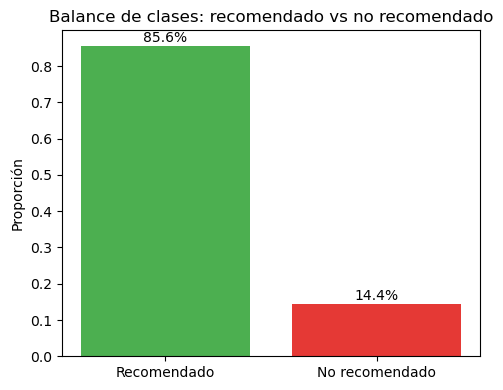

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
prop = stats["proporcion_recomendado"][0]
ax.bar(["Recomendado", "No recomendado"], [prop, 1 - prop], color=["#4CAF50", "#E53935"])
ax.set_ylabel("Proporción")
ax.set_title("Balance de clases: recomendado vs no recomendado")
for i, v in enumerate([prop, 1 - prop]):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

In [17]:
# Distribución de reviews por usuario
reviews_por_usuario = (
    lf.group_by(COLMAP["user_id"])
      .agg(pl.len().alias("n_reviews"))
      .collect()
)

print(reviews_por_usuario["n_reviews"].describe())
print()
print("Usuarios con 1 sola review (cold-start puro):",
      f"{(reviews_por_usuario['n_reviews'] == 1).sum():,}",
      f"({100*(reviews_por_usuario['n_reviews'] == 1).mean():.1f}%)")

shape: (9, 2)
┌────────────┬─────────────┐
│ statistic  ┆ value       │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ count      ┆ 3.7918537e7 │
│ null_count ┆ 0.0         │
│ mean       ┆ 3.003313    │
│ std        ┆ 8.149466    │
│ min        ┆ 1.0         │
│ 25%        ┆ 1.0         │
│ 50%        ┆ 1.0         │
│ 75%        ┆ 3.0         │
│ max        ┆ 9822.0      │
└────────────┴─────────────┘

Usuarios con 1 sola review (cold-start puro): 20,869,389 (55.0%)


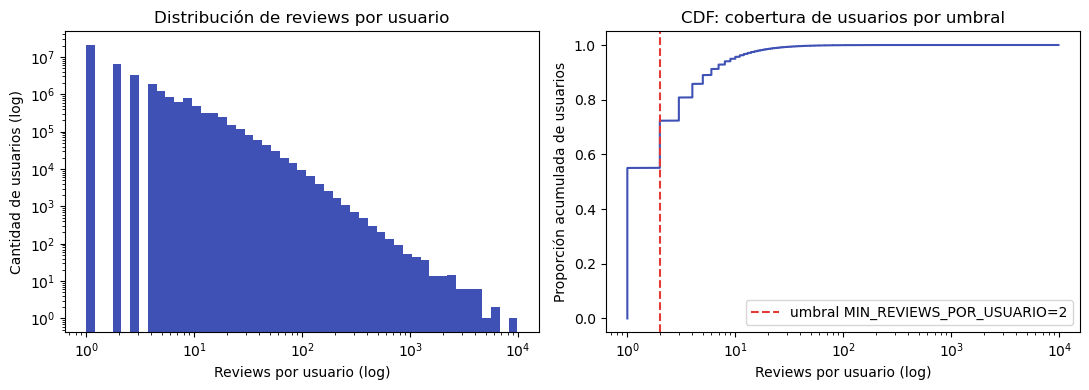

In [16]:
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histograma en escala log-log: con distribuciones de cola larga (power-law-like),
# una escala lineal solo muestra una barra gigante en "1-2 reviews" y nada más.
counts = reviews_por_usuario["n_reviews"].to_numpy()
bins = np.logspace(0, np.log10(counts.max()), 50)
axes[0].hist(counts, bins=bins, color="#3F51B5", edgecolor="none")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Reviews por usuario (log)")
axes[0].set_ylabel("Cantidad de usuarios (log)")
axes[0].set_title("Distribución de reviews por usuario")

# Curva acumulada: qué % de usuarios queda cubierto hasta cierto umbral de reviews.
sorted_counts = np.sort(counts)
cum_pct = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
axes[1].plot(sorted_counts, cum_pct, color="#3F51B5")
axes[1].set_xscale("log")
axes[1].axvline(2, color="#E53935", linestyle="--", label="umbral MIN_REVIEWS_POR_USUARIO=2")
axes[1].set_xlabel("Reviews por usuario (log)")
axes[1].set_ylabel("Proporción acumulada de usuarios")
axes[1].set_title("CDF: cobertura de usuarios por umbral")
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# Distribución de reviews por juego — juegos con pocas reviews son ruido para ALS
reviews_por_juego = (
    lf.group_by(COLMAP["item_id"])
      .agg(pl.len().alias("n_reviews"))
      .collect()
)
print(reviews_por_juego["n_reviews"].describe())

shape: (9, 2)
┌────────────┬──────────────┐
│ statistic  ┆ value        │
│ ---        ┆ ---          │
│ str        ┆ f64          │
╞════════════╪══════════════╡
│ count      ┆ 105893.0     │
│ null_count ┆ 0.0          │
│ mean       ┆ 1075.436969  │
│ std        ┆ 28798.377983 │
│ min        ┆ 1.0          │
│ 25%        ┆ 4.0          │
│ 50%        ┆ 16.0         │
│ 75%        ┆ 78.0         │
│ max        ┆ 7.704382e6   │
└────────────┴──────────────┘


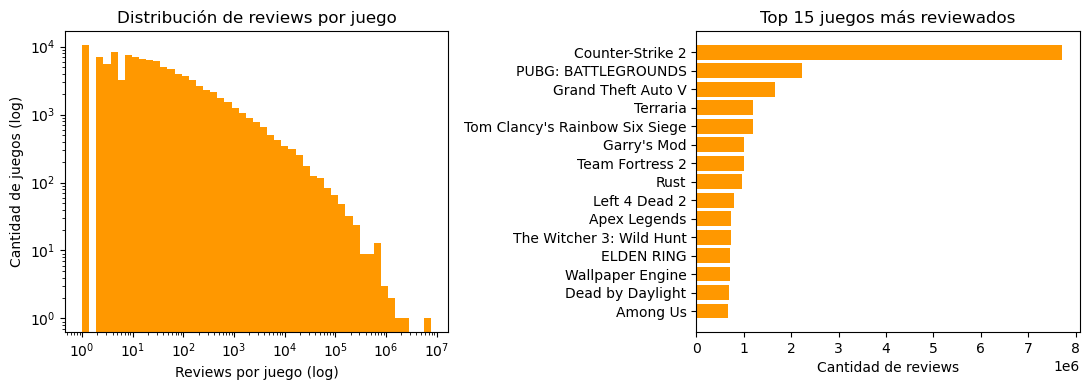

In [22]:
GAME_NAME_COL = "game"

# Traemos el nombre desde el parquet original
game_names = (
    pl.scan_parquet(PARQUET_PATH)
      .select([
          pl.col(COLMAP["item_id"]).alias("item_id"),
          pl.col(GAME_NAME_COL).alias("game_name"),
      ])
      .unique(subset=["item_id"])
      .collect()
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts_juego = reviews_por_juego["n_reviews"].to_numpy()
bins = np.logspace(0, np.log10(counts_juego.max()), 50)
axes[0].hist(counts_juego, bins=bins, color="#FF9800", edgecolor="none")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Reviews por juego (log)")
axes[0].set_ylabel("Cantidad de juegos (log)")
axes[0].set_title("Distribución de reviews por juego")

top_n = (
    reviews_por_juego.sort("n_reviews", descending=True).head(15)
      .rename({COLMAP["item_id"]: "item_id"})
      .join(game_names, on="item_id", how="left")
      .with_columns(pl.col("game_name").fill_null(pl.col("item_id").cast(pl.Utf8)))  # fallback si no matchea
)

axes[1].barh(
    top_n["game_name"].to_list()[::-1],
    top_n["n_reviews"].to_list()[::-1],
    color="#FF9800",
)
axes[1].set_xlabel("Cantidad de reviews")
axes[1].set_title("Top 15 juegos más reviewados")

plt.tight_layout()
plt.show()

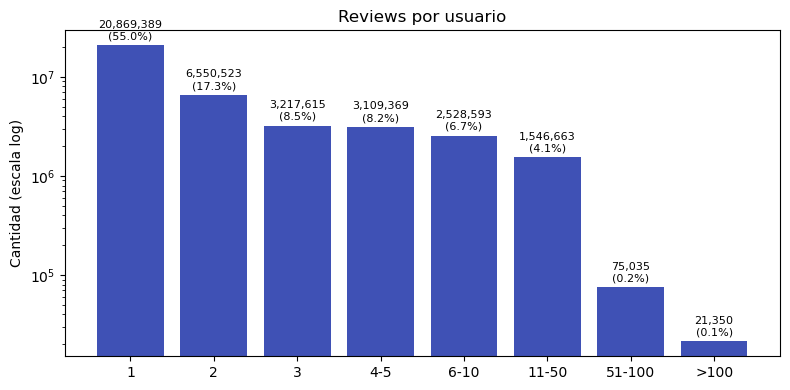

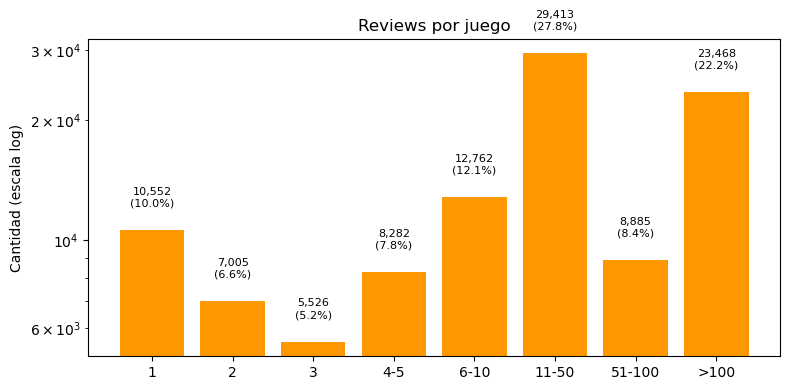

In [20]:
def bucketizar(df: pl.DataFrame, col: str = "n_reviews") -> pl.DataFrame:
    return df.with_columns(
        pl.when(pl.col(col) == 1).then(pl.lit("1"))
          .when(pl.col(col) == 2).then(pl.lit("2"))
          .when(pl.col(col) == 3).then(pl.lit("3"))
          .when(pl.col(col) <= 5).then(pl.lit("4-5"))
          .when(pl.col(col) <= 10).then(pl.lit("6-10"))
          .when(pl.col(col) <= 50).then(pl.lit("11-50"))
          .when(pl.col(col) <= 100).then(pl.lit("51-100"))
          .otherwise(pl.lit(">100"))
          .alias("bucket")
    )

BUCKET_ORDER = ["1", "2", "3", "4-5", "6-10", "11-50", "51-100", ">100"]

def contar_buckets(df: pl.DataFrame, col: str = "n_reviews") -> pl.DataFrame:
    conteo = (
        bucketizar(df, col)
          .group_by("bucket")
          .agg(pl.len().alias("n"))
    )
    # reindexar según BUCKET_ORDER para que el gráfico salga en orden lógico, no alfabético
    orden_df = pl.DataFrame({"bucket": BUCKET_ORDER})
    return orden_df.join(conteo, on="bucket", how="left").fill_null(0)


def graficar_buckets(conteo: pl.DataFrame, titulo: str, color: str):
    fig, ax = plt.subplots(figsize=(8, 4))
    n = conteo["n"].to_numpy()
    ax.bar(BUCKET_ORDER, n, color=color)
    ax.set_yscale("log")  # log solo en el eje Y -- el rango entre buckets sigue siendo de varios
                           # órdenes de magnitud (millones vs. decenas), el eje X ya es categórico
    ax.set_ylabel("Cantidad (escala log)")
    ax.set_title(titulo)
    total = n.sum()
    for i, v in enumerate(n):
        if v > 0:
            ax.text(i, v * 1.15, f"{v:,}\n({100*v/total:.1f}%)", ha="center", fontsize=8)
    plt.tight_layout()
    plt.show()


# --- Usuarios ---
conteo_usuarios = contar_buckets(reviews_por_usuario, "n_reviews")
graficar_buckets(conteo_usuarios, "Reviews por usuario", "#3F51B5")

# --- Juegos ---
conteo_juegos = contar_buckets(reviews_por_juego, "n_reviews")
graficar_buckets(conteo_juegos, "Reviews por juego", "#FF9800")

## 5. Filtrado y limpieza

Considerando el volumen de los datos, asi como el funcionamiento de ALS (Alternating Least Squares) se toman algunas decisiones:

- Eliminar usuarios con **menos de 2 reviews** — con 1 sola interacción, ALS no tiene nada que aprender de ese usuario (Tambien llamado cold-start, esto se resolverá mas adelante con otra solución).
- Eliminar juegos con **menos de 5 reviews** — juegos sumamente "niche" o poco conocidos. Estos podrian reducir la calidad de los embeddings y agregar ruido.

Al tomar estas acciones se pierde cobertura sobre algunos usuarios y juegos, pero se gana un modelo mas afinado y en espcial mas liviano.

In [23]:
MIN_REVIEWS_POR_USUARIO = 2
MIN_REVIEWS_POR_JUEGO = 5

# Se filtran usuarios y juegos por encima de estos limites. Se usa Lazyfram 
usuarios_validos = (
    reviews_por_usuario.filter(pl.col("n_reviews") >= MIN_REVIEWS_POR_USUARIO)
      .select(pl.col(COLMAP["user_id"]).alias("user_id"))
      .lazy()
)
juegos_validos = (
    reviews_por_juego.filter(pl.col("n_reviews") >= MIN_REVIEWS_POR_JUEGO)
      .select(pl.col(COLMAP["item_id"]).alias("item_id"))
      .lazy()
)

print(f"Usuarios antes del filtro: {reviews_por_usuario.height:,} -> después: {usuarios_validos.select(pl.len()).collect().item():,}")
print(f"Juegos antes del filtro:   {reviews_por_juego.height:,} -> después: {juegos_validos.select(pl.len()).collect().item():,}")

Usuarios antes del filtro: 37,918,537 -> después: 17,049,148
Juegos antes del filtro:   105,893 -> después: 78,385


In [24]:
# Basados en los Lazyframe previos, se filtra (mediante join) los registros a conservar.

OUT_DIR = DATA_DIR / "processed"
OUT_DIR.mkdir(exist_ok=True)
CLEAN_PATH = OUT_DIR / "steam_reviews_clean.parquet"

(
    lf.select(cols_needed)
      .rename({v: k for k, v in COLMAP.items()})
      .join(usuarios_validos, on="user_id", how="semi")
      .join(juegos_validos, on="item_id", how="semi")
      .filter(pl.col("recommended").is_not_null())
      .sink_parquet(CLEAN_PATH)   # streaming a disco, no carga las ~90-100M filas resultantes en RAM
)

df_clean_preview = pl.scan_parquet(CLEAN_PATH)
n_clean = df_clean_preview.select(pl.len()).collect().item()
print(f"Filas despues del filtro: {n_clean:,}")
df_clean_preview.head(5).collect()

Filas despues del filtro: 92,958,418


user_id,item_id,recommended,timestamp,timestamp_updated,playtime
i64,i64,i64,i64,i64,i64
76561198028252309,434650,1,1575375715,1575375715,572
76561197995052837,435150,1,1543113900,1543113900,2334
76561198823806006,714010,1,1606781931,1606781931,488
76561198072582606,304430,1,1611595804,1611595804,345
76561198020170209,751780,1,1561910227,1561910227,2944


## 6. Encoding a índices enteros consecutivos

El siguiente paso es una preparacion necesaria previa de los datos.<br>
Una csr_matrix (Compressed Sparce Row Matrix) genera un arreglo de n + 1 numero de filas. Los SteamID usualmente tienen un formato similar a 76561198324251650, si se utilizara tal cual, seria una matriz gigantezca que no cabria en memoria.<br>
Adicionalmente, el algoritmo a utilizar en proximos pasos (ALS) requiere una matriz continua basada en 0. Por lo que los SteamID y AppID no funcionarian sin tratamiento previo.

In [25]:
# Cargamos el parquet limpio ya filtrado
df_clean = pl.read_parquet(CLEAN_PATH)
print(f"Filas cargadas en memoria: {df_clean.height:,}")
print(f"Memoria aprox: {df_clean.estimated_size('mb'):.1f} MB")

Filas cargadas en memoria: 92,958,418
Memoria aprox: 4255.4 MB


In [26]:
# Se preparan las columnas de user_idx e item_idx que contendran el indice generado. Partiendo en 0.
# rank(method="dense") asigna enteros consecutivos (1,2,3...) a los valores únicos, en orden.
df_clean = df_clean.with_columns([
    (pl.col("user_id").rank(method="dense").cast(pl.Int32) - 1).alias("user_idx"),
    (pl.col("item_id").rank(method="dense").cast(pl.Int32) - 1).alias("item_idx"),
    pl.col("recommended").cast(pl.Int8),
])

n_users = df_clean["user_idx"].max() + 1
n_items = df_clean["item_idx"].max() + 1
print(f"n_users: {n_users:,} | n_items: {n_items:,}")
print(f"Densidad de la matriz: {df_clean.height / (n_users * n_items):.6%}")

n_users: 17,049,073 | n_items: 78,376
Densidad de la matriz: 0.006957%


In [28]:
# Guardamos los mapeos idx -> id original (necesarios para interpretar recomendaciones después)
user_map = df_clean.select(["user_id", "user_idx"]).unique(subset=["user_idx"]).sort("user_idx")
item_map = df_clean.select(["item_id", "item_idx"]).unique(subset=["item_idx"]).sort("item_idx")

OUT_DIR = DATA_DIR / "processed"
OUT_DIR.mkdir(exist_ok=True)

user_map.write_parquet(OUT_DIR / "user_map.parquet")
item_map.write_parquet(OUT_DIR / "item_map.parquet")

cols_final = ["user_idx", "item_idx", "recommended", "timestamp"] if "timestamp" in df_clean.columns else ["user_idx", "item_idx", "recommended"]
df_clean.select(cols_final).write_parquet(OUT_DIR / "steam_reviews_clean.parquet")

print("Guardado en:", OUT_DIR)
for f in OUT_DIR.iterdir():
    print(f"  {f.name:35s} {f.stat().st_size/1e6:8.1f} MB")

Guardado en: datasets/parquet/steam/reviews/processed
  user_map.parquet                        70.3 MB
  item_map.parquet                         0.3 MB
  .ipynb_checkpoints                       0.0 MB
  steam_reviews_clean.parquet            907.4 MB
